In [2]:
from sklearn import linear_model
reg = linear_model.Ridge(alpha=.5)
reg.fit([[0,0], [0,0], [1,1]], [0, .1, 1])
print(reg.coef_)
print(reg.intercept_)

[0.34545455 0.34545455]
0.13636363636363638


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

X = 1.0 / (np.arange(1, 11) + np.arange(0, 10)[:, np.newaxis])  # 加一个新维度
X

array([[1.        , 0.5       , 0.33333333, 0.25      , 0.2       ,
        0.16666667, 0.14285714, 0.125     , 0.11111111, 0.1       ],
       [0.5       , 0.33333333, 0.25      , 0.2       , 0.16666667,
        0.14285714, 0.125     , 0.11111111, 0.1       , 0.09090909],
       [0.33333333, 0.25      , 0.2       , 0.16666667, 0.14285714,
        0.125     , 0.11111111, 0.1       , 0.09090909, 0.08333333],
       [0.25      , 0.2       , 0.16666667, 0.14285714, 0.125     ,
        0.11111111, 0.1       , 0.09090909, 0.08333333, 0.07692308],
       [0.2       , 0.16666667, 0.14285714, 0.125     , 0.11111111,
        0.1       , 0.09090909, 0.08333333, 0.07692308, 0.07142857],
       [0.16666667, 0.14285714, 0.125     , 0.11111111, 0.1       ,
        0.09090909, 0.08333333, 0.07692308, 0.07142857, 0.06666667],
       [0.14285714, 0.125     , 0.11111111, 0.1       , 0.09090909,
        0.08333333, 0.07692308, 0.07142857, 0.06666667, 0.0625    ],
       [0.125     , 0.11111111, 0.1      

In [4]:
y = np.ones(10)
y

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [5]:
n_alphas = 200
alphas = np.logspace(-10, -2, n_alphas)
print(alphas)
coefs = []
for a in alphas:
    ridge = linear_model.Ridge(alpha=a, fit_intercept=False)  # 纯线性,无截距
    ridge.fit(X, y)
    coefs.append(ridge.coef_)

[1.00000000e-10 1.09698580e-10 1.20337784e-10 1.32008840e-10
 1.44811823e-10 1.58856513e-10 1.74263339e-10 1.91164408e-10
 2.09704640e-10 2.30043012e-10 2.52353917e-10 2.76828663e-10
 3.03677112e-10 3.33129479e-10 3.65438307e-10 4.00880633e-10
 4.39760361e-10 4.82410870e-10 5.29197874e-10 5.80522552e-10
 6.36824994e-10 6.98587975e-10 7.66341087e-10 8.40665289e-10
 9.22197882e-10 1.01163798e-09 1.10975250e-09 1.21738273e-09
 1.33545156e-09 1.46497140e-09 1.60705282e-09 1.76291412e-09
 1.93389175e-09 2.12145178e-09 2.32720248e-09 2.55290807e-09
 2.80050389e-09 3.07211300e-09 3.37006433e-09 3.69691271e-09
 4.05546074e-09 4.44878283e-09 4.88025158e-09 5.35356668e-09
 5.87278661e-09 6.44236351e-09 7.06718127e-09 7.75259749e-09
 8.50448934e-09 9.32930403e-09 1.02341140e-08 1.12266777e-08
 1.23155060e-08 1.35099352e-08 1.48202071e-08 1.62575567e-08
 1.78343088e-08 1.95639834e-08 2.14614120e-08 2.35428641e-08
 2.58261876e-08 2.83309610e-08 3.10786619e-08 3.40928507e-08
 3.73993730e-08 4.102658

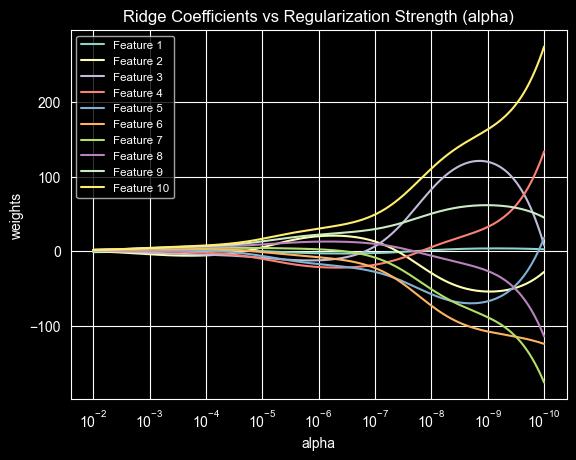

In [6]:
ax = plt.gca()

ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlim(ax.get_xlim()[::-1])  # 反转x轴
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge Coefficients vs Regularization Strength (alpha)")
plt.axis("tight")
plt.legend([f"Feature {i+1}" for i in range(X.shape[1])], loc="best", fontsize="small")  # loc="best" 自动选择最佳位置
plt.show()

## Leave-one-out Cross Validation

In [2]:
import numpy as np
from sklearn import linear_model
reg = linear_model.RidgeCV(alphas=np.logspace(-6,6,13))  # 默认cv=None,即留一法交叉验证
reg.fit([[0,0],[0,0],[1,1]],[0,.1,1])

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","array([1.e-06...e+05, 1.e+06])"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


In [3]:
reg.alpha_

0.01

In [ ]:
# 加入cv=...,(假设输入10)则变为10折交叉验证,加快计算